# 02. create_deep_agent - 기본 사용법

이 노트북에서는 **`create_deep_agent()`** 를 사용하여 Deep Agent를 간단하게 생성하고 활용하는 방법을 학습합니다.

## 학습 목표

- **`create_deep_agent()` 이해**: 한 줄로 Deep Agent 생성
- **기본 제공 기능**: File System, TODO Planning, SubAgents가 자동으로 포함됨
- **OpenAI 모델 사용**: gpt-4o, gpt-4o-mini 등 사용
- **Custom Tools 추가**: 웹 검색 등 커스텀 도구 통합
- **System Prompt 커스터마이징**: 에이전트 역할 정의


### create_deep_agent
```python
# 한 줄로 모든 기능 포함!
agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[internet_search],
    system_prompt=research_instructions,
)
```

**자동으로 포함되는 기능:**
- Virtual File System (ls, read_file, write_file, edit_file)
- TODO Planning (write_todos)
- SubAgent spawning (task)
- Auto-Summarization (긴 대화 자동 요약)
- 최적화된 System Prompt

## 1. 환경 설정

In [25]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. deepagents 설치 및 import

`deepagents` 패키지는 별도 설치가 필요합니다.

https://github.com/langchain-ai/deepagents

In [26]:
from deepagents import create_deep_agent

## 3. Custom Tool 정의: Web Search

Research Agent를 만들기 위해 웹 검색 도구를 추가합니다.

In [27]:
import os
from typing import Literal
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

## 4. System Prompt 정의

Research Agent의 역할과 행동 방식을 정의합니다.

In [95]:
RESEARCH_INSTRUCTIONS = """당신은 전문 연구자입니다. 당신의 임무는 철저한 조사를 수행한 후, 정리된 보고서를 작성하는 것입니다.

인터넷 검색 도구를 주요 정보 수집 수단으로 사용할 수 있습니다.

## Workflow
1. **Plan**: write_todos를 사용하여 연구 과제를 단계별로 나눕니다. 
2. **Research**: internet_search를 사용하여 정보를 수집합니다.
3. **Save**: write_file을 사용하여 중요한 정보를 파일에 저장합니다.
4. **Synthesize**: 저장된 파일을 읽고 종합적인 보고서를 작성합니다.

## Best Practices
- 검색 결과를 파일에 저장하여 재검색을 피하세요.
- 파일 시스템을 사용하여 정보를 체계적으로 정리하세요.
- 명확하고 잘 구조화된 보고서를 작성하세요.
- 자료의 출처를 명확히 기록하세요.
"""

## 5. Deep Agent 생성

이제 `create_deep_agent()`로 한 줄에 Agent를 생성합니다!

In [112]:
agent = create_deep_agent(
    model="openai:gpt-5.4",  # OpenAI 모델 사용 "openai:gpt-4o-mini"
    tools=[internet_search],      # Custom tools 추가
    system_prompt=RESEARCH_INSTRUCTIONS,  # System prompt 설정
)

## 6. Agent 그래프 시각화

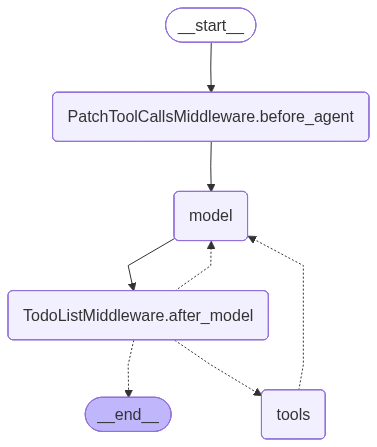

In [113]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

## 7. Agent 실행

이제 Agent를 실행하고 어떻게 작동하는지 확인해봅시다.

**[예시 Input]**
- LangGraph가 무엇인지 조사하고 입문자 온보딩을 위한 보고서를 작성해주세요.
- ChatGPT, Claude, Gemini의 최신 요금제 정보를 수집해 정리하고, 이를 비교 분석한 뒤 어떤 선택이 가장 합리적인지 비교한 보고서를 만들어줘.

### 7.1. 리서치 요청

In [114]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": """웹에서 ChatGPT, Claude, Gemini의 최신 요금제 정보를 수집해 정리하고,
            이를 비교 분석한 뒤 어떤 선택이 가장 합리적인지 비교한 보고서를 만들어줘."""
        }
    ]
})

In [115]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

웹에서 ChatGPT, Claude, Gemini의 최신 요금제 정보를 수집해 정리하고,
            이를 비교 분석한 뒤 어떤 선택이 가장 합리적인지 비교한 보고서를 만들어줘.
================================== Ai Message ==================================

[{'arguments': '{"todos":[{"content":"최신 요금제 조사 계획 수립 및 작업 디렉터리 확인", "status":"in_progress"},{"content":"웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집", "status":"pending"},{"content":"수집한 정보 파일로 저장", "status":"pending"},{"content":"저장된 자료를 바탕으로 비교 분석 보고서 작성", "status":"pending"}]}', 'call_id': 'call_oPzITeo85MCxc8HTv5xhD7BQ', 'name': 'write_todos', 'type': 'function_call', 'id': 'fc_027103bd4f65311e0069e72452a87881949b2852a59ff55260', 'status': 'completed'}]
Tool Calls:
  write_todos (call_oPzITeo85MCxc8HTv5xhD7BQ)
 Call ID: call_oPzITeo85MCxc8HTv5xhD7BQ
  Args:
    todos: [{'content': '최신 요금제 조사 계획 수립 및 작업 디렉터리 확인', 'status': 'in_progress'}, {'content': '웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집', 'status': 'pending'}, 

In [100]:
# user_message = [
#         {
#             "role": "user",
#             "content": "LangGraph가 무엇인지 조사하고 입문자 온보딩을 위한 보고서를 작성해주세요."
#         }
#     ]

# for chunk in agent.stream({"messages": user_message}, stream_mode="updates"):
#     print("\n=== 업데이트 ===")
#     for node, value in chunk.items():
#         print(f"노드: {node}")
#         if value and "messages" in value:
#             print(value["messages"])

### 7.2. 최종 응답 확인

In [116]:
from IPython.display import Markdown
final_message = result["messages"][-1]

display(Markdown(final_message.content[0]["text"]))

보고서를 작성해 저장했습니다.

- 조사 노트: `/pricing_research_notes.md`
- 최종 보고서: `/pricing_comparison_report.md`

핵심 결론만 요약하면:

- **가장 범용적으로 합리적**: **ChatGPT Plus**
- **문서 작성·요약·리서치 중심이면**: **Claude Pro**
- **Gmail, Docs, Drive, Meet를 중심으로 일하면**: **Gemini Google AI Pro 계열**

확인된 공식 가격 중 핵심은:
- **ChatGPT Plus**: 월 **$20**
- **ChatGPT Pro**: 월 **$200**
- **Claude Pro**: 월 **$20**
- **Claude Team**: 사용자당 월 **$25**

주의할 점:
- Gemini와 일부 상위/업무용 플랜은 공식 페이지가 검색 결과에서 **가격 숫자를 완전히 노출하지 않아**, 보고서에선 기능 중심으로 비교했습니다.
- 따라서 **정확한 최종 결제 금액**은 구매 직전 공식 페이지에서 다시 확인하는 게 안전합니다.

원하면 다음 중 하나로 이어서 해줄 수 있습니다:
1. 보고서를 **표 중심 1페이지 요약본**으로 재작성
2. **개인용만** 추려서 더 간단히 정리
3. **팀/회사 도입 관점**으로만 다시 비교
4. **한국 원화 환산 예시**까지 붙여서 정리

In [117]:
result["files"]

{'/large_tool_results/call_BEy7lhOmHjPNlkBbJM5OcbMm': {'content': '{"query": "Claude pricing Pro Max Team Enterprise", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://claude.com/pricing/enterprise", "title": "Enterprise plan | Claude by Anthropic", "content": "The Enterprise plan offers critical security and data management components including single sign-on (SSO) and domain capture for secure user access and centralized provisioning control, audit logs that trace system activities for security and compliance monitoring, system for Cross-domain Identity Management (SCIM) to automate user provisioning and access controls, and role-based permissioning that assigns a single primary owner of a workspace for security and information management. Based on the uploaded user feedback survey and analytics report, create a product requirements document for a new feature that addresses the main user pain points identified in the data. Include the product vi

In [118]:
result["files"].keys()

dict_keys(['/large_tool_results/call_BEy7lhOmHjPNlkBbJM5OcbMm', '/large_tool_results/call_E2wMEJ3pM9M5z7OUxubDCGCP', '/pricing_research_notes.md', '/pricing_comparison_report.md'])

In [119]:
from IPython.display import Markdown

print("\n" + "="*60)
print("📄 AGENT의 최종 보고서")
print("="*60 + "\n")

display(Markdown(result["files"]['/pricing_comparison_report.md']["content"]))


📄 AGENT의 최종 보고서



# ChatGPT vs Claude vs Gemini 최신 요금제 비교 보고서

작성일: 2026-04-21
기준: 공식 가격 페이지 중심 웹 조사

## 1. 요약 결론

가장 합리적인 선택은 사용 목적에 따라 달라진다.

- **대부분의 개인 사용자**: **ChatGPT Plus** 또는 **Claude Pro**가 가장 합리적이다.
- **글쓰기·문서 분석·긴 컨텍스트 중심 사용자**: **Claude Pro** 쪽이 더 매력적이다.
- **범용성·멀티모달·도구 생태계·커스텀 GPT 활용**: **ChatGPT Plus**가 더 유리하다.
- **Gmail, Docs, Drive, Meet 등 Google 생태계를 이미 깊게 쓰는 사용자**: **Gemini/Google AI Pro 계열**이 가장 자연스럽다.
- **파워유저/전문직/연구·개발 고사용량**: ChatGPT Pro, Claude Max, Gemini Ultra가 후보지만, 가격이 급격히 올라가므로 ROI가 명확할 때만 합리적이다.
- **팀/조직**: 보안과 관리 기능이 중요하면 세 서비스 모두 엔터프라이즈 옵션이 있으나, Google Workspace를 이미 쓰는 조직은 Gemini, 협업형 AI 워크플로는 Claude, 범용 AI 플랫폼·앱 커넥터는 ChatGPT가 유리하다.

**단일 추천을 하나만 고르면:**
- **가장 보편적으로 무난한 선택 = ChatGPT Plus**
- **문서 작업/리서치 집중형 최고의 가성비 = Claude Pro**
- **구글 워크스페이스 사용자에게 가장 합리적 = Gemini Google AI Pro 계열**

---

## 2. 조사 범위 및 유의사항

- 조사 대상: ChatGPT, Claude, Gemini의 최신 구독형 요금제
- 기준 자료: 공식 가격 페이지 중심
- 유의사항:
  - 지역, 통화, 세금, 프로모션에 따라 실제 청구액은 달라질 수 있다.
  - 일부 공식 페이지는 검색 인덱싱 과정에서 가격 숫자가 완전하게 노출되지 않았다.
  - 따라서 **가격 숫자가 공식 검색 결과에서 명확히 확인된 항목만 단정적으로 기재**했다.

---

## 3. 서비스별 요금제 정리

## 3.1 ChatGPT

공식 출처: https://chatgpt.com/pricing/

### 개인용
- Free: 무료
- Go: 공식 페이지 존재, 다만 이번 검색 추출에서는 가격 숫자 미확인
- Plus: **월 20달러**
- Pro: **월 200달러**

### 업무용
- Business: 사용자당 월 과금, 연간/월간 과금 제공, 숫자 가격은 이번 검색 추출에서 미확인
- Enterprise: 영업 문의

### 특징 요약
- Plus:
  - 고급 추론 모델 접근
  - 메시지/업로드 확대
  - 더 빠른 이미지 생성
  - Deep Research / Agent Mode 확대
  - Projects, Tasks, Custom GPTs
  - 신기능 조기 접근
- Pro:
  - GPT-5.4 Pro
  - GPT-5.4 및 파일 업로드 사실상 최상위 수준 접근
  - Deep Research / Agent Mode 최대 사용
  - 우선 속도 Codex
- Business/Enterprise:
  - SAML SSO, MFA, 관리 기능
  - 각종 앱 커넥터
  - 비즈니스 데이터 기본 학습 제외
  - Enterprise는 SCIM, EKM, RBAC, 데이터 레지던시 등 제공

### 해석
ChatGPT는 가장 범용적인 구성이다. 개인용에서는 Plus가 사실상 핵심 상품이고, Pro는 일반 사용자에게는 과투자일 가능성이 높다.

---

## 3.2 Claude

공식 출처:
- https://claude.com/pricing
- https://claude.com/pricing/max
- https://claude.com/pricing/team
- https://claude.com/pricing/enterprise

### 개인용
- Free: 무료
- Pro: **월 20달러**
- Max 5x: 공식 페이지 존재, 이번 검색 추출에서는 숫자 미확인
- Max 20x: 공식 페이지 존재, 이번 검색 추출에서는 숫자 미확인

### 팀/기업용
- Team: **사용자당 월 25달러**(월간 기준으로 검색 결과 확인)
- Enterprise self-serve:
  - 좌석당 월 과금
  - 사용량은 API 요율에 따라 추가 청구
  - 최소 20석, 연간 약정
- Enterprise sales-assisted:
  - 최소 50석
  - 맞춤 계약

### 특징 요약
- Pro:
  - 고사용량 개인용
  - Claude Code, Research, Artifacts 등 상위 기능 접근
- Max:
  - Pro 대비 세션당 최대 5배 또는 20배 사용량
  - 최신 모델/기능 우선 접근
- Team:
  - 협업, 프로젝트 공유, 커스텀 스타일, 연구 리포트, Claude Code
- Enterprise:
  - SSO, SCIM, 감사 로그, 데이터 보존 제어, 컴플라이언스 API
  - 사용량 분석, HIPAA-ready 옵션

### 해석
Claude는 특히 **문장 품질, 문서 이해, 리서치 흐름, 긴 컨텍스트 활용** 쪽에서 경쟁력이 크다. Pro가 20달러라면 개인 사용자에게 매우 강한 가성비 구간이다.

---

## 3.3 Gemini / Google AI

공식 출처:
- https://one.google.com/about/google-ai-plans/
- https://one.google.com/about/
- https://workspace.google.com/pricing

### 개인용 Google AI 플랜
- Google AI Plus: 공식 페이지 존재, 이번 검색 추출에서는 가격 숫자 미확인
- Google AI Pro: 공식 페이지 존재, 이번 검색 추출에서는 가격 숫자 미확인
- Google AI Ultra: 공식 페이지 존재, 이번 검색 추출에서는 가격 숫자 미확인

### 개인용 특징 요약
- AI Plus:
  - 200GB 저장공간
  - Gemini 앱 접근 확대
  - 128K 컨텍스트
  - Deep Research / NotebookLM / Flow 사용량 증가
- AI Pro:
  - 2TB 저장공간
  - 1M 컨텍스트
  - Gemini in Gmail / Docs / Workspace 확장
  - NotebookLM, Code Assist, Jules 상향
  - Google Cloud 월 10달러 크레딧
- AI Ultra:
  - 30TB 저장공간
  - 1M 컨텍스트
  - 최고 수준 사용량
  - Deep Think, Gemini Agent, Project Mariner/Genie
  - YouTube Premium 포함
  - Google Cloud 월 100달러 크레딧

### Workspace 비즈니스 플랜
- Business Starter / Standard / Plus / Enterprise
- 숫자 가격은 검색 결과가 현지화 언어로 노출되어 안정적 확인 실패
- 기능 차이는 확인 가능:
  - Starter: AI 접근 제한적
  - Standard 이상: Gemini in Docs / Sheets / Slides / Drive / Meet / Chat 제공
  - Enterprise: 사용자 수 상한 없음, 엔터프라이즈 관리/보안 강화

### 해석
Gemini는 **AI 단독 상품**이라기보다 **Google 생태계 결합 상품**의 성격이 강하다. Gmail, Docs, Drive, Meet, NotebookLM, 저장공간, 유튜브/클라우드 크레딧 같은 번들 가치까지 함께 봐야 합리성이 높아진다.

---

## 4. 핵심 비교

## 4.1 월 20달러급 개인 요금제 비교

이번 조사에서 명확히 확인된 20달러급은 다음 두 가지다.

- ChatGPT Plus: 월 20달러
- Claude Pro: 월 20달러

Gemini Pro 계열도 시장에서 유사 가격대일 가능성이 높지만, 이번 공식 검색 추출로는 숫자 확인이 불충분했다.

### ChatGPT Plus가 더 나은 경우
- 이미지, 음성, 웹 검색, 커스텀 GPT 등 **범용 기능을 넓게 쓰고 싶을 때**
- 업무 자동화나 다양한 실험을 자주 할 때
- 최신 AI 기능을 빠르게 체험하고 싶을 때
- 하나의 서비스로 최대한 많은 사용 사례를 커버하고 싶을 때

### Claude Pro가 더 나은 경우
- 긴 글 작성, 요약, 편집, 보고서 구성 등 **문서 중심 작업**이 많을 때
- 긴 문맥 기반 분석이 중요할 때
- 차분하고 일관된 글쓰기 품질을 중시할 때
- 코드 설명, 설계 논의, 리서치 구조화가 중요할 때

### 현 시점 판단
- 범용성 기준: **ChatGPT Plus 우위**
- 문서/리서치 기준: **Claude Pro 우위**
- 가성비 자체는 둘 다 매우 강함

---

## 4.2 고가 플랜 비교

### ChatGPT Pro
- 월 200달러로 가격이 매우 높다.
- 일반 사용자에게는 과하다.
- 다만 반복적 고강도 사용, 고급 추론, 파일 분석, 연구/개발 등에서 시간을 크게 절감하면 투자 가치가 생긴다.

### Claude Max
- Pro보다 훨씬 높은 사용량을 주는 상위 플랜
- 특히 Claude를 업무 중심 툴로 오래 쓰는 사용자에게 적합
- 다만 가격 숫자 확인이 불완전하므로 ROI 판단은 공식 페이지 재확인이 필요

### Gemini Ultra
- 단순 챗봇 요금제가 아니라 저장공간, 유튜브, 고급 AI 접근, 각종 부가 기능이 결합된 초프리미엄 번들에 가깝다.
- 이미 Google 서비스에 비용을 많이 쓰는 사용자라면 체감 가치가 올라간다.

### 현 시점 판단
고가 플랜은 “최고 성능”보다는 **시간 절약 금액 > 구독료**가 명확할 때만 합리적이다.

---

## 4.3 팀/조직 관점 비교

### ChatGPT Business / Enterprise
적합한 경우:
- 다양한 외부 앱/도구 연결이 중요할 때
- 범용 AI 비서 플랫폼이 필요할 때
- 사내에서 여러 업무군이 공통으로 쓰는 AI 허브가 필요할 때

### Claude Team / Enterprise
적합한 경우:
- 리서치, 문서 생산, 분석 협업, 코드 협업이 핵심일 때
- 팀 단위로 AI 결과물 품질과 일관성을 중시할 때
- 지식작업자 중심 조직일 때

### Gemini Workspace / Enterprise
적합한 경우:
- 회사가 이미 Google Workspace 중심일 때
- Gmail, Docs, Slides, Meet 안에서 바로 AI를 쓰고 싶을 때
- 별도 툴 도입보다 기존 워크플로 내 통합이 중요할 때

### 현 시점 판단
- **기존에 Google Workspace가 강하면 Gemini가 가장 자연스럽다.**
- **문서·분석 협업이 중심이면 Claude가 강하다.**
- **범용 플랫폼성과 확장성은 ChatGPT가 강하다.**

---

## 5. 어떤 선택이 가장 합리적인가?

## 5.1 개인 사용자 기준 추천

### 1순위: ChatGPT Plus
추천 대상:
- 가장 무난한 만능형 선택을 원하는 사람
- 글쓰기, 검색, 이미지, 음성, 아이디어 정리, 코딩 보조를 모두 쓰는 사람
- 하나만 구독할 생각인 사람

추천 이유:
- 20달러 구간에서 기능 폭이 넓다.
- 활용 범위가 넓어서 실패 확률이 낮다.
- 툴 생태계와 멀티모달이 강점이다.

### 2순위: Claude Pro
추천 대상:
- 글쓰기/편집/보고서/독해 작업 비중이 높은 사람
- 긴 문서와 복잡한 맥락을 다루는 사람
- AI의 답변 톤과 글 품질을 중요하게 보는 사람

추천 이유:
- 역시 20달러 구간의 강력한 가성비 상품이다.
- 특히 지식노동과 문서 기반 업무에서 만족도가 높을 가능성이 크다.

### 3순위: Gemini Google AI Pro 계열
추천 대상:
- Gmail, Docs, Drive, Meet를 매일 쓰는 사람
- Google One 저장공간, NotebookLM, Workspace 통합까지 같이 가치로 보는 사람

추천 이유:
- 단일 챗봇 성능만이 아니라 구글 생태계 전체 생산성 향상을 본다면 매우 합리적이다.
- 다만 독립형 AI만 놓고 비교하면 가치 판단이 사용자 환경에 크게 좌우된다.

---

## 5.2 직군별 추천

### 학생 / 일반 사무직
- 1순위: ChatGPT Plus
- 대안: Google Workspace를 이미 많이 쓰면 Gemini

### 작가 / 마케터 / 기획자 / 컨설턴트
- 1순위: Claude Pro
- 대안: 범용성과 이미지/툴 활용이 중요하면 ChatGPT Plus

### 개발자 / PM / 리서처
- 1순위: ChatGPT Plus 또는 Claude Pro
- 선택 기준:
  - 다양한 도구·멀티모달·실험성: ChatGPT
  - 설계 대화·문서·리서치 구조화: Claude

### Google 중심 직장인 / 스타트업
- 1순위: Gemini Workspace 또는 Google AI Pro 계열
- 이유: 도입 마찰이 가장 낮다

---

## 6. 최종 한줄 추천

- **하나만 고르라면:** ChatGPT Plus
- **문서 작업이 핵심이면:** Claude Pro
- **Google 생태계 안에서 일하면:** Gemini Google AI Pro 계열
- **고가 플랜은:** 실제 생산성 절감액이 구독료를 넘길 때만 선택

---

## 7. 출처

- ChatGPT Pricing: https://chatgpt.com/pricing/
- Claude Pricing: https://claude.com/pricing
- Claude Max: https://claude.com/pricing/max
- Claude Team: https://claude.com/pricing/team
- Claude Enterprise: https://claude.com/pricing/enterprise
- Google AI Plans: https://one.google.com/about/google-ai-plans/
- Google One Overview: https://one.google.com/about/
- Google Workspace Pricing: https://workspace.google.com/pricing


### 7.3. 전체 대화 흐름 확인

In [120]:
def format_messages_detailed(messages):
    """메시지를 상세하게 포맷팅합니다."""
    for i, msg in enumerate(messages):
        if hasattr(msg, 'type'):
            msg_type = msg.type
        else:
            msg_type = msg.get('role', 'unknown')

        print(f"\n{'='*60}")
        print(f"[{i+1}] {msg_type.upper()}")
        print(f"{'='*60}")

        if msg_type == 'ai' and hasattr(msg, 'tool_calls') and msg.tool_calls:
            # Tool calls 표시
            print(f"\n🔧 Agent가 {len(msg.tool_calls)}개의 도구를 호출합니다:")
            for j, tool_call in enumerate(msg.tool_calls, 1):
                tool_name = tool_call.get('name', 'unknown')
                args = tool_call.get('args', {})
                print(f"\n  [{j}] {tool_name}")
                for key, value in args.items():
                    value_str = str(value)
                    print(f"      - {key}: {value_str}")
        elif msg_type == 'tool':
            # Tool 결과 표시
            tool_name = getattr(msg, 'name', 'unknown')
            content = msg.content if hasattr(msg, 'content') else str(msg)
            print(f"\n📦 Tool Result ({tool_name}):")

            # 내용이 너무 길면 잘라서 표시
            if len(str(content)) > 500:
                print(f"{str(content)[:500]}...\n(총 {len(str(content))} 문자)")
            else:
                print(content)
        else:
            # 일반 메시지
            content = msg.content if hasattr(msg, 'content') else msg.get('content', str(msg))
            print(content)

print("\n\n" + "#"*60)
print("# 전체 대화 흐름")
print("#"*60)

format_messages_detailed(result["messages"])



############################################################
# 전체 대화 흐름
############################################################

[1] HUMAN
웹에서 ChatGPT, Claude, Gemini의 최신 요금제 정보를 수집해 정리하고,
            이를 비교 분석한 뒤 어떤 선택이 가장 합리적인지 비교한 보고서를 만들어줘.

[2] AI

🔧 Agent가 1개의 도구를 호출합니다:

  [1] write_todos
      - todos: [{'content': '최신 요금제 조사 계획 수립 및 작업 디렉터리 확인', 'status': 'in_progress'}, {'content': '웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집', 'status': 'pending'}, {'content': '수집한 정보 파일로 저장', 'status': 'pending'}, {'content': '저장된 자료를 바탕으로 비교 분석 보고서 작성', 'status': 'pending'}]

[3] TOOL

📦 Tool Result (write_todos):
Updated todo list to [{'content': '최신 요금제 조사 계획 수립 및 작업 디렉터리 확인', 'status': 'in_progress'}, {'content': '웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집', 'status': 'pending'}, {'content': '수집한 정보 파일로 저장', 'status': 'pending'}, {'content': '저장된 자료를 바탕으로 비교 분석 보고서 작성', 'status': 'pending'}]

[4] AI

🔧 Agent가 4개의 도구를 호출합니다:

  [1] ls
      - path: /

  [2] internet_search
      -

### 7.4. 파일 시스템 상태 확인

In [121]:
print("\n" + "="*60)
print("📁 VIRTUAL FILE SYSTEM 상태")
print("="*60)

files = result.get("files", {})

if not files:
    print("\nAgent가 파일을 생성하지 않았습니다.")
else:
    print(f"\n📊 총 {len(files)}개의 파일이 생성되었습니다:\n")

    for file_path, content in files.items():
        print(f"\n{'─'*60}")
        print(f"📄 {file_path}")
        print(f"{'─'*60}")
        print(f"크기: {len(content["content"])} 문자")

        # 내용 미리보기 (처음 500자)
        print(f"\n[내용 미리보기]")
        print(content["content"][:500])
        if len(content["content"]) > 500:
            print(f"\n... ({len(content["content"]) - 500}자 더 있음)")


📁 VIRTUAL FILE SYSTEM 상태

📊 총 4개의 파일이 생성되었습니다:


────────────────────────────────────────────────────────────
📄 /large_tool_results/call_BEy7lhOmHjPNlkBbJM5OcbMm
────────────────────────────────────────────────────────────
크기: 109680 문자

[내용 미리보기]
{"query": "Claude pricing Pro Max Team Enterprise", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://claude.com/pricing/enterprise", "title": "Enterprise plan | Claude by Anthropic", "content": "The Enterprise plan offers critical security and data management components including single sign-on (SSO) and domain capture for secure user access and centralized provisioning control, audit logs that trace system activities for security and compliance monitoring,

... (109180자 더 있음)

────────────────────────────────────────────────────────────
📄 /large_tool_results/call_E2wMEJ3pM9M5z7OUxubDCGCP
────────────────────────────────────────────────────────────
크기: 145890 문자

[내용 미리보기]
{"query": "Gemini Business Ent

### 7.5. TODO 추적 (State 확인)

In [122]:
if "todos" in result:
    print("\n" + "="*60)
    print("TODO LIST 상태")
    print("="*60 + "\n")

    todos = result["todos"]
    print(todos)
    for i, todo in enumerate(todos, 1):
        status = todo.get("status", "unknown")
        content = todo.get("content", "No Content")

        print(f"[{i}] {content} ({status})")


TODO LIST 상태

[{'content': '최신 요금제 조사 계획 수립 및 작업 디렉터리 확인', 'status': 'completed'}, {'content': '웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집', 'status': 'completed'}, {'content': '수집한 정보 파일로 저장', 'status': 'completed'}, {'content': '저장된 자료를 바탕으로 비교 분석 보고서 작성', 'status': 'completed'}]
[1] 최신 요금제 조사 계획 수립 및 작업 디렉터리 확인 (completed)
[2] 웹 검색으로 ChatGPT, Claude, Gemini 최신 요금제 정보 수집 (completed)
[3] 수집한 정보 파일로 저장 (completed)
[4] 저장된 자료를 바탕으로 비교 분석 보고서 작성 (completed)
